In [ ]:
Name: Vrunda S (25MCAR0041)
      Pavana V (25MCAR0171)
      Nikith M (25MCAR0013) 

In [1]:
pip install opencv-python numpy matplotlib scikit-image

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

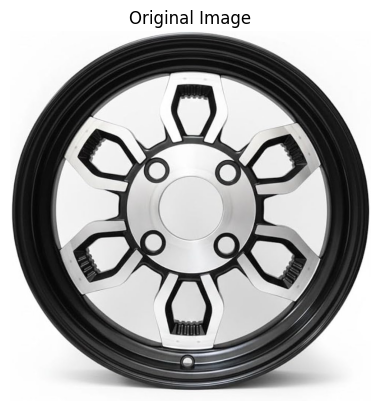

In [3]:
image = cv2.imread("wheel.jpg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


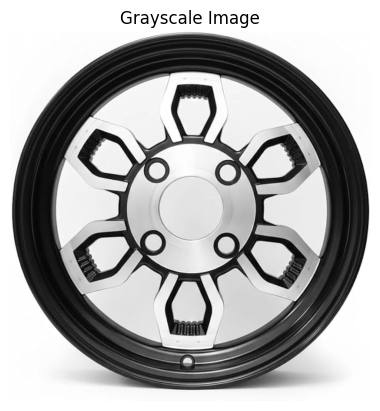

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

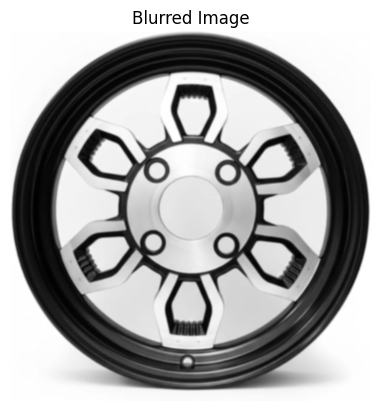

In [5]:
blur = cv2.GaussianBlur(gray,(9,9),2)

plt.imshow(blur,cmap='gray')
plt.title("Blurred Image")
plt.axis("off")
plt.show()

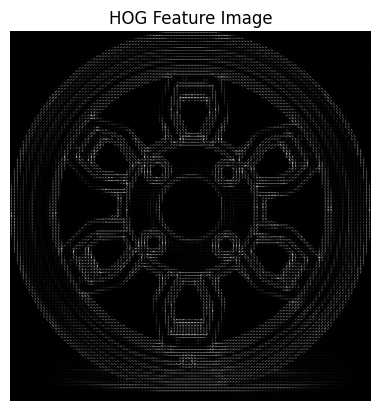

In [6]:
features, hog_image = hog(
 blur,
 orientations=9,
 pixels_per_cell=(8,8),
 cells_per_block=(2,2),
 visualize=True
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0,10))

plt.imshow(hog_image_rescaled,cmap='gray')
plt.title("HOG Feature Image")
plt.axis("off")
plt.show()


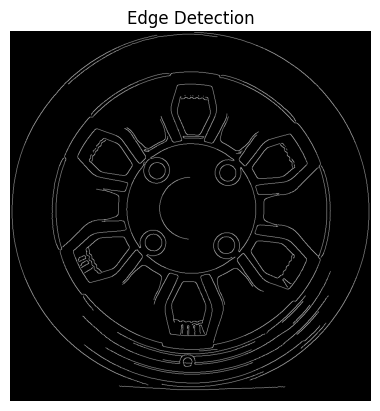

In [7]:
edges = cv2.Canny(blur,50,150)

plt.imshow(edges,cmap='gray')
plt.title("Edge Detection")
plt.axis("off")
plt.show()

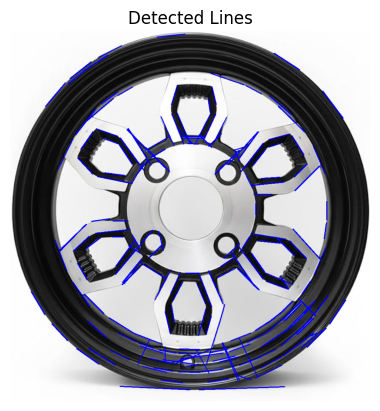

In [10]:
lines = cv2.HoughLinesP(
 edges,
 1,
 np.pi/180,
 threshold=60,
 minLineLength=30,
 maxLineGap=20
)

line_output = image.copy()

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        cv2.line(line_output,(x1,y1),(x2,y2),(255,0,0),2)

plt.imshow(cv2.cvtColor(line_output, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines")
plt.axis("off")
plt.show()

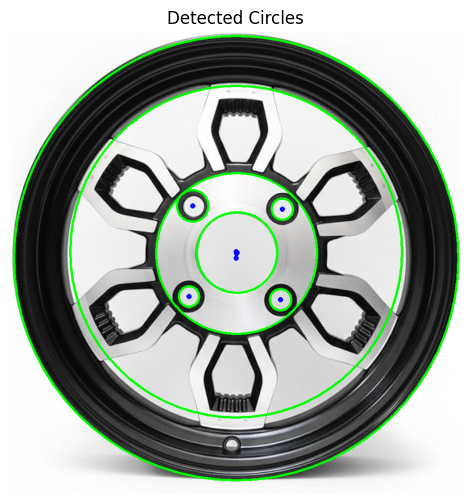

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("wheel.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray,(9,9),2)

circle_output = image.copy()

outer = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=400,
    param1=120,
    param2=60,
    minRadius=420,
    maxRadius=520
)

inner_rim = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=300,
    param1=120,
    param2=50,
    minRadius=260,
    maxRadius=360
)

hub_ring = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=200,
    param1=120,
    param2=40,
    minRadius=130,
    maxRadius=210
)

center = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=200,
    param1=120,
    param2=45,
    minRadius=60,
    maxRadius=120
)

bolts = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=120,
    param2=30,
    minRadius=15,
    maxRadius=35
)

h, w = gray.shape
cx, cy = w//2, h//2

for group in [outer, inner_rim, hub_ring, center, bolts]:

    if group is None:
        continue

    circles = np.round(group[0]).astype("int")

    for (x,y,r) in circles:

        # keep circles near center
        if abs(x-cx) > 150 or abs(y-cy) > 150:
            continue

        cv2.circle(circle_output,(x,y),r,(0,255,0),3)
        cv2.circle(circle_output,(x,y),3,(255,0,0),4)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(circle_output, cv2.COLOR_BGR2RGB))
plt.title("Detected Circles")
plt.axis("off")
plt.show()